> **NOTEBOOK: 01-dataset-cleaning**

---

# Arduino Code Repair - CodeT5 Fine-Tuning (V2)

**Duinophile University Project**

This notebook fine-tunes `Salesforce/codet5-small` on an expanded Arduino code repair dataset.

**V2 Dataset:** 2,678 examples covering 80 error types (syntax + logical errors)

## Setup
1. Upload `arduino_repair_dataset_v2.csv` as a Kaggle Dataset
2. Enable **GPU T4 x2** in Kaggle Settings
3. Run all cells
4. Download the trained model from the Output section

In [1]:
# ====================================================
# NOTEBOOK: 01-dataset-cleaning
# ====================================================

# ─── CELL 1: Install Dependencies ────────────────────────────────────────────
!pip install -q transformers datasets accelerate sentencepiece
!pip install -q -U transformers==4.44.0 datasets accelerate sentencepiece peft


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 68.0 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 96.3 MB/s eta 0:00:00:00:01


In [2]:
# ====================================================
# NOTEBOOK: 01-dataset-cleaning
# ====================================================

# ─── CELL 2: Imports ─────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import torch
import os
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    DataCollatorForSeq2Seq,
)

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

2026-04-22 01:38:33.172730: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776821913.389396      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776821913.455612      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776821914.003449      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776821914.003490      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776821914.003494      55 computation_placer.cc:177] computation placer alr

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
GPU Memory: 15.6 GB


In [4]:
# ====================================================
# NOTEBOOK: 01-dataset-cleaning
# ====================================================

# ─── CELL 3: Configuration ───────────────────────────────────────────────────

# === CHANGE THIS PATH TO YOUR KAGGLE DATASET ===
# After uploading arduino_repair_dataset_v2.csv as a Kaggle Dataset,
# the path will be like: /kaggle/input/<your-dataset-name>/arduino_repair_dataset_v2.csv
DATA_PATH = '/kaggle/input/datasets/dinirugamage/arduino-fixed-model/arduino_repair_dataset_v2.csv'

# Model Configuration
MODEL_NAME = 'Salesforce/codet5-small'  # 60M params, good for free GPU
OUTPUT_DIR = '/kaggle/working/arduino_fixed_model'

# Training Hyperparameters
MAX_INPUT_LENGTH = 512   # Max tokens for buggy code input
MAX_OUTPUT_LENGTH = 512  # Max tokens for fixed code output
BATCH_SIZE = 4           # Increase if GPU has more memory
LEARNING_RATE = 3e-5     # Slightly lower for bigger dataset
NUM_EPOCHS = 25          # Bigger dataset needs fewer epochs
WARMUP_STEPS = 150
WEIGHT_DECAY = 0.01
SEED = 42

print('Configuration loaded.')
print(f'  Model: {MODEL_NAME}')
print(f'  Epochs: {NUM_EPOCHS}')
print(f'  Batch Size: {BATCH_SIZE}')
print(f'  Learning Rate: {LEARNING_RATE}')

Configuration loaded.
  Model: Salesforce/codet5-small
  Epochs: 25
  Batch Size: 4
  Learning Rate: 3e-05


In [5]:
# ====================================================
# NOTEBOOK: 01-dataset-cleaning
# ====================================================

# ─── CELL 4: Load Dataset ────────────────────────────────────────────────────

# Check if file exists
if os.path.exists(DATA_PATH):
    print(f'Dataset found: {DATA_PATH}')
else:
    print(f'Dataset NOT found at: {DATA_PATH}')
    print('\nLooking for CSV files in /kaggle/input/ ...')
    for root, dirs, files in os.walk('/kaggle/input/'):
        for f in files:
            if f.endswith('.csv'):
                full = os.path.join(root, f)
                print(f'  Found: {full}')
    raise FileNotFoundError(f'Please update DATA_PATH. File not found: {DATA_PATH}')

df = pd.read_csv(DATA_PATH)
print(f'\nTotal examples: {len(df)}')
print(f'Columns: {list(df.columns)}')
print(f'\nError type distribution:')
print(df['error_type'].value_counts().head(15))
print(f'\n--- Sample ---')
print(f'Input:  {df.iloc[0]["input"][:150]}...')
print(f'Output: {df.iloc[0]["output"][:150]}...')

Dataset found: /kaggle/input/datasets/dinirugamage/arduino-fixed-model/arduino_repair_dataset_v2.csv

Total examples: 2678
Columns: ['input', 'output', 'template', 'error_type']

Error type distribution:
error_type
wrong_formula               37
wrong_pin_mode              31
no_error                    30
misspelled_keyword          30
missing_bracket             30
missing_close_paren         30
wrong_pin_number            30
extra_semicolon             30
missing_single_semicolon    30
extra_parenthesis           30
missing_open_bracket        30
missing_semicolon           30
wrong_casing                29
truncated_name              28
assignment_vs_comparison    27
Name: count, dtype: int64

--- Sample ---
Input:  fix: int sensorPin=A0;
int ledPin=13;
int threshold=500;
void setup(){inMode(ledPin,OUTPUT);}
void loop(){int val=analogRead(sensorPin);if(val>thresho...
Output: int sensorPin=A0;
int ledPin=13;
int thresholdHigh=550;
int thresholdLow=450;
void setup(){pinMode(ledPin,OU

In [6]:
# ====================================================
# NOTEBOOK: 02-model-finetuning
# ====================================================

# ─── CELL 5: Prepare Train/Val Split ─────────────────────────────────────────

# Shuffle the data
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

# 85% train, 15% validation
split_idx = int(len(df) * 0.85)
train_df = df[:split_idx]
val_df = df[split_idx:]

print(f'Train: {len(train_df)} examples')
print(f'Val:   {len(val_df)} examples')

# Convert to HuggingFace Dataset
train_dataset = Dataset.from_pandas(train_df[['input', 'output']], preserve_index=False)
val_dataset = Dataset.from_pandas(val_df[['input', 'output']], preserve_index=False)

dataset = DatasetDict({
    'train': train_dataset,
    'validation': val_dataset,
})

print(f'\nDataset ready:')
print(dataset)

Train: 2276 examples
Val:   402 examples

Dataset ready:
DatasetDict({
    train: Dataset({
        features: ['input', 'output'],
        num_rows: 2276
    })
    validation: Dataset({
        features: ['input', 'output'],
        num_rows: 402
    })
})


In [7]:
# ====================================================
# NOTEBOOK: 02-model-finetuning
# ====================================================

# ─── CELL 6: Load Tokenizer & Model ──────────────────────────────────────────

print(f'Loading {MODEL_NAME}...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
print(f'Tokenizer vocab size: {tokenizer.vocab_size}')
print('Model loaded successfully!')

Loading Salesforce/codet5-small...


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/242M [00:00<?, ?B/s]

Total parameters:     60,492,288
Trainable parameters: 60,492,288
Tokenizer vocab size: 32100
Model loaded successfully!


In [8]:
# ====================================================
# NOTEBOOK: 02-model-finetuning
# ====================================================

# ─── CELL 7: Tokenize Dataset ────────────────────────────────────────────────

def preprocess_function(examples):
    """Tokenize input (buggy code) and output (fixed code)."""
    inputs = examples['input']
    targets = examples['output']
    
    # Tokenize inputs
    model_inputs = tokenizer(
        inputs,
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        padding='max_length',
    )
    
    # Tokenize targets
    labels = tokenizer(
        targets,
        max_length=MAX_OUTPUT_LENGTH,
        truncation=True,
        padding='max_length',
    )
    
    # Replace padding token ids with -100 so they are ignored in loss
    label_ids = labels['input_ids']
    label_ids = [
        [(token if token != tokenizer.pad_token_id else -100) for token in label]
        for label in label_ids
    ]
    
    model_inputs['labels'] = label_ids
    return model_inputs


print('Tokenizing dataset...')
tokenized_dataset = dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=['input', 'output'],
    desc='Tokenizing'
)

print(f'\nTokenized dataset:')
print(tokenized_dataset)
print(f'\nSample tokenized input length: {len(tokenized_dataset["train"][0]["input_ids"])}')
print(f'Sample tokenized label length: {len(tokenized_dataset["train"][0]["labels"])}')

Tokenizing dataset...


Tokenizing:   0%|          | 0/2276 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/402 [00:00<?, ? examples/s]


Tokenized dataset:
DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 2276
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 402
    })
})

Sample tokenized input length: 512
Sample tokenized label length: 512


In [9]:
# ====================================================
# NOTEBOOK: 03-hyperparameter-config
# ====================================================

# ─── CELL 8: Quick Sanity Check ──────────────────────────────────────────────
# Verify that tokenization is reversible

sample = tokenized_dataset['train'][0]
decoded_input = tokenizer.decode(sample['input_ids'], skip_special_tokens=True)
decoded_labels = tokenizer.decode([t for t in sample['labels'] if t != -100], skip_special_tokens=True)

print('=== SANITY CHECK ===')
print(f'\nDecoded INPUT (first 200 chars):')
print(decoded_input[:200])
print(f'\nDecoded OUTPUT (first 200 chars):')
print(decoded_labels[:200])
print('\nIf these look like buggy and fixed Arduino code, tokenization is correct!')

=== SANITY CHECK ===

Decoded INPUT (first 200 chars):
fix: int sensorPin = A0;

void setup() {
  Serial.begin(9600);
}

void loop() {
  int reading = analogRead(sensorPin);
  float temperature = reading * 5.0 / 1124.0;
  Serial.print("Temp: ");
  Serial.

Decoded OUTPUT (first 200 chars):
int sensorPin = A0;

void setup() {
  Serial.begin(9600);
}

void loop() {
  int reading = analogRead(sensorPin);
  float temperature = (reading * 5.0 / 1123.0 - 0.5) * 110;
  Serial.print("Temp: ");


If these look like buggy and fixed Arduino code, tokenization is correct!


In [10]:
# ====================================================
# NOTEBOOK: 03-hyperparameter-config
# ====================================================

# ─── CELL 9: Define Training Arguments ───────────────────────────────────────

training_args = Seq2SeqTrainingArguments(
    output_dir=OUTPUT_DIR,
    
    # Training
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    warmup_steps=WARMUP_STEPS,
    lr_scheduler_type='cosine',
    
    # Evaluation
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    
    # Generation settings for evaluation
    predict_with_generate=True,
    generation_max_length=MAX_OUTPUT_LENGTH,
    
    # Logging
    logging_dir=f'{OUTPUT_DIR}/logs',
    logging_steps=10,
    report_to='none',
    
    # Optimization
    fp16=torch.cuda.is_available(),  # Use mixed precision on GPU
    gradient_accumulation_steps=4,   # Effective batch = 4*4 = 16
    save_total_limit=3,              # Keep only 3 best checkpoints
    
    seed=SEED,
)

print('Training arguments configured.')
print(f'  Effective batch size: {BATCH_SIZE * 4} (batch={BATCH_SIZE} x accumulation=4)')
print(f'  Mixed precision (fp16): {training_args.fp16}')
print(f'  Total training steps: ~{(len(tokenized_dataset["train"]) // (BATCH_SIZE * 4)) * NUM_EPOCHS}')

Training arguments configured.
  Effective batch size: 16 (batch=4 x accumulation=4)
  Mixed precision (fp16): True
  Total training steps: ~3550


In [13]:
# ====================================================
# NOTEBOOK: 04-model-training
# ====================================================

# ─── CELL 10: Compute Metrics ────────────────────────────────────────────────
# We'll compute exact match accuracy during evaluation

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    
    # Clip predictions to valid token ID range (fixes OverflowError)
    predictions = np.where(predictions < 0, tokenizer.pad_token_id, predictions)
    predictions = np.where(predictions >= tokenizer.vocab_size, tokenizer.pad_token_id, predictions)
    
    # Decode predictions
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    
    # Replace -100 in labels with pad_token_id for decoding
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    
    # Exact match accuracy
    exact_matches = sum(
        1 for pred, label in zip(decoded_preds, decoded_labels)
        if pred.strip() == label.strip()
    )
    accuracy = exact_matches / len(decoded_preds)
    
    return {'exact_match_accuracy': accuracy}

print('Metrics function defined.')


Metrics function defined.


In [14]:
# ====================================================
# NOTEBOOK: 04-model-training
# ====================================================

# ─── CELL 11: Create Trainer & Start Training ────────────────────────────────

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True,
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['validation'],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print('=' * 60)
print(f'  STARTING TRAINING: {NUM_EPOCHS} epochs')
print(f'  Train examples: {len(tokenized_dataset["train"])}')
print(f'  Val examples:   {len(tokenized_dataset["validation"])}')
print('=' * 60)

# Train!
train_result = trainer.train()

print('\n' + '=' * 60)
print('TRAINING COMPLETE!')
print('=' * 60)
print(f'  Total steps:  {train_result.global_step}')
print(f'  Train loss:   {train_result.training_loss:.4f}')
print(f'  Train time:   {train_result.metrics["train_runtime"]:.0f}s')

  STARTING TRAINING: 25 epochs
  Train examples: 2276
  Val examples:   402


Epoch,Training Loss,Validation Loss,Exact Match Accuracy
0,0.468400,0.294973,0.022388
1,0.224300,0.138866,0.099502
2,0.119200,0.057244,0.310945
4,0.042400,0.016218,0.746269
5,0.033500,0.011070,0.825871
6,0.026700,0.007903,0.850746
8,0.014300,0.005451,0.902985
9,0.011600,0.004588,0.922886
10,0.011800,0.004379,0.937811
12,0.007600,0.003797,0.942786


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector


TRAINING COMPLETE!
  Total steps:  1775
  Train loss:   0.0554
  Train time:   5379s


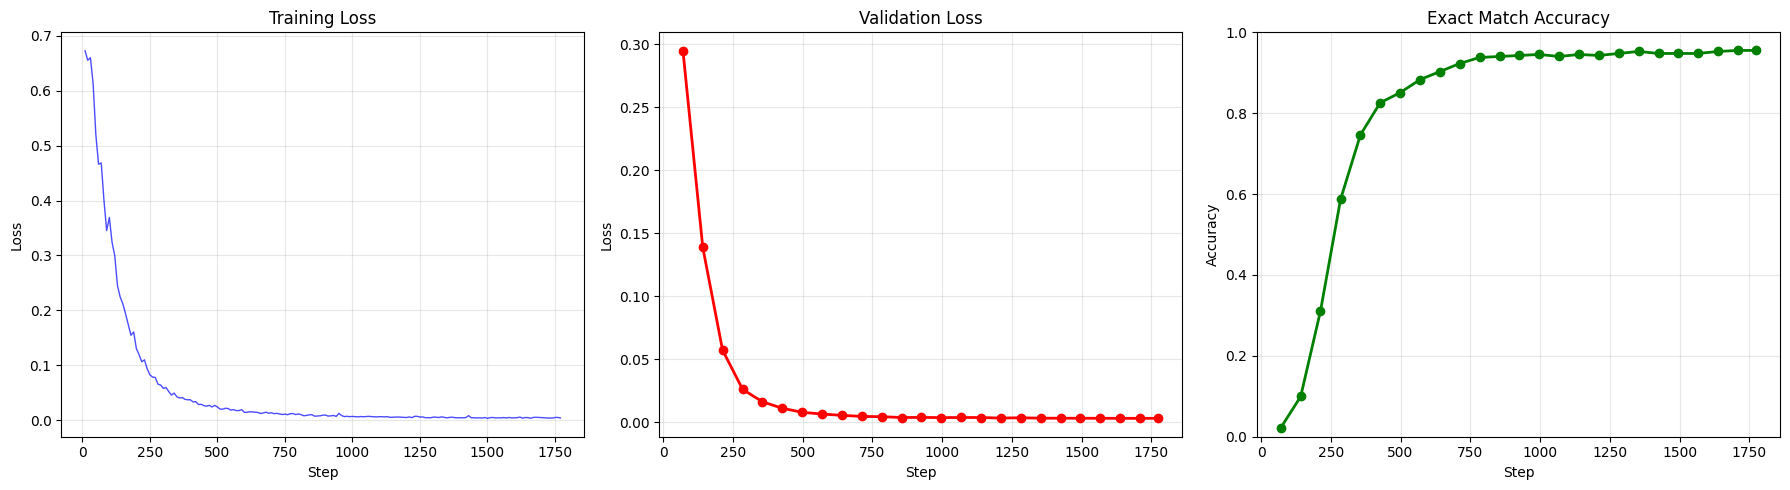

Best eval loss: 0.0031
Best exact match accuracy: 95.52%


In [15]:
# ====================================================
# NOTEBOOK: 04-model-training
# ====================================================

# ─── CELL 12: Plot Training Curves ───────────────────────────────────────────
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

# Extract training loss per step
train_steps = [x['step'] for x in log_history if 'loss' in x]
train_losses = [x['loss'] for x in log_history if 'loss' in x]

# Extract eval loss per epoch
eval_steps = [x['step'] for x in log_history if 'eval_loss' in x]
eval_losses = [x['eval_loss'] for x in log_history if 'eval_loss' in x]
eval_accuracy = [x.get('eval_exact_match_accuracy', 0) for x in log_history if 'eval_loss' in x]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Training Loss
axes[0].plot(train_steps, train_losses, 'b-', alpha=0.7, linewidth=1)
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].grid(True, alpha=0.3)

# Plot 2: Eval Loss
axes[1].plot(eval_steps, eval_losses, 'r-o', linewidth=2)
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Loss')
axes[1].set_title('Validation Loss')
axes[1].grid(True, alpha=0.3)

# Plot 3: Exact Match Accuracy
axes[2].plot(eval_steps, eval_accuracy, 'g-o', linewidth=2)
axes[2].set_xlabel('Step')
axes[2].set_ylabel('Accuracy')
axes[2].set_title('Exact Match Accuracy')
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Best eval loss: {min(eval_losses):.4f}')
if eval_accuracy:
    print(f'Best exact match accuracy: {max(eval_accuracy):.2%}')

In [18]:
# ====================================================
# NOTEBOOK: 05-model-evaluation
# ====================================================

# ─── CELL 13: Save Best Model ────────────────────────────────────────────────

FINAL_MODEL_DIR = '/kaggle/working/arduino_fixed_model'

# Save model + tokenizer together
trainer.save_model(FINAL_MODEL_DIR)
tokenizer.save_pretrained(FINAL_MODEL_DIR)

# List saved files
print('Model saved to:', FINAL_MODEL_DIR)
print('\nFiles:')
for f in sorted(os.listdir(FINAL_MODEL_DIR)):
    size = os.path.getsize(os.path.join(FINAL_MODEL_DIR, f))
    print(f'  {f:<40} {size/1e6:.1f} MB')


Model saved to: /kaggle/working/arduino_fixed_model

Files:
  checkpoint-1638                          0.0 MB
  checkpoint-1710                          0.0 MB
  checkpoint-1775                          0.0 MB
  config.json                              0.0 MB
  generation_config.json                   0.0 MB
  merges.txt                               0.3 MB
  model.safetensors                        242.0 MB
  special_tokens_map.json                  0.0 MB
  tokenizer.json                           1.4 MB
  tokenizer_config.json                    0.0 MB
  training_args.bin                        0.0 MB
  vocab.json                               0.5 MB


In [19]:
# ====================================================
# NOTEBOOK: 05-model-evaluation
# ====================================================

# ─── CELL 14: Load Saved Model & Define fix_code ────────────────────────────

# Load the saved model for testing
print('Loading saved model for testing...')
test_tokenizer = AutoTokenizer.from_pretrained(FINAL_MODEL_DIR)
test_model = AutoModelForSeq2SeqLM.from_pretrained(FINAL_MODEL_DIR)
test_model.eval()

if torch.cuda.is_available():
    test_model = test_model.cuda()


def fix_code(buggy_code, model, tokenizer):
    """Given buggy Arduino code, return the model's fix."""
    prompt = f'fix: {buggy_code}'
    inputs = tokenizer(prompt, return_tensors='pt', max_length=512, truncation=True)
    if torch.cuda.is_available():
        inputs = {k: v.cuda() for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_length=512,
            num_beams=5,
            early_stopping=True,
            no_repeat_ngram_size=0,
        )
    
    result = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return result


print('Model loaded! Running test cases...\n')


Loading saved model for testing...
Model loaded! Running test cases...



In [20]:
# ====================================================
# NOTEBOOK: 05-model-evaluation
# ====================================================

# ─── CELL 15: Run Test Cases ─────────────────────────────────────────────────

test_cases = [
    {
        'name': '1. Missing semicolon',
        'buggy': 'void setup() {\n  pinMode(LED_BUILTIN, OUTPUT);\n}\n\nvoid loop() {\n  digitalWrite(LED_BUILTIN, HIGH);\n  delay(1000);\n  digitalWrite(LED_BUILTIN, LOW)\n  delay(1000);\n}',
        'expected_fix': 'Add semicolon after LOW)',
    },
    {
        'name': '2. Wrong function casing',
        'buggy': 'void setup() {\n  pinmode(13, OUTPUT);\n}\n\nvoid loop() {\n  digitalwrite(13, HIGH);\n  delay(1000);\n  digitalwrite(13, LOW);\n  delay(1000);\n}',
        'expected_fix': 'pinmode -> pinMode, digitalwrite -> digitalWrite',
    },
    {
        'name': '3. Truncated function name',
        'buggy': 'void setup() {\n  pinMode(LED_BUILTIN, OUTPUT);\n}\n\nvoid loop() {\n  igitalWrite(LED_BUILTIN, HIGH);\n  delay(1000);\n  igitalWrite(LED_BUILTIN, LOW);\n  delay(1000);\n}',
        'expected_fix': 'igitalWrite -> digitalWrite',
    },
    {
        'name': '4. Multiple errors combined',
        'buggy': 'void setup() {\n  pinmode(13, OUTPUT);\n}\n\nvoid loop() {\n  digitalwrite(13, HIGH)\n  delay(1000);\n  digitalwrite(13, LOW)\n  delay(1000);\n}',
        'expected_fix': 'Fix casing AND add semicolons',
    },
    {
        'name': '5. Wrong pin mode (LOGICAL)',
        'buggy': 'int buttonPin = 2;\nint ledPin = 13;\nvoid setup() {\n  pinMode(buttonPin, OUTPUT);\n  pinMode(ledPin, OUTPUT);\n}\nvoid loop() {\n  int state = digitalRead(buttonPin);\n  if (state == HIGH) {\n    digitalWrite(ledPin, HIGH);\n  }\n}',
        'expected_fix': 'buttonPin should be INPUT not OUTPUT',
    },
    {
        'name': '6. Assignment vs comparison (LOGICAL)',
        'buggy': 'int sensorPin = A0;\nvoid setup() {\n  Serial.begin(9600);\n}\nvoid loop() {\n  int val = analogRead(sensorPin);\n  if (val = 500) {\n    Serial.println("Threshold!");\n  }\n  delay(100);\n}',
        'expected_fix': 'if (val = 500) -> if (val == 500)',
    },
    {
        'name': '7. Missing delay in loop (LOGICAL)',
        'buggy': 'void setup() {\n  Serial.begin(9600);\n}\nvoid loop() {\n  Serial.println("Hello");\n}',
        'expected_fix': 'Add delay() to prevent serial flooding',
    },
    {
        'name': '8. Wrong data type for millis (LOGICAL)',
        'buggy': 'int ledPin = 13;\nint previousMillis = 0;\nint interval = 1000;\nvoid setup() {\n  pinMode(ledPin, OUTPUT);\n}\nvoid loop() {\n  int currentMillis = millis();\n  if (currentMillis - previousMillis >= interval) {\n    previousMillis = currentMillis;\n    digitalWrite(ledPin, !digitalRead(ledPin));\n  }\n}',
        'expected_fix': 'int -> unsigned long for millis variables',
    },
    {
        'name': '9. Correct code (should pass through)',
        'buggy': 'void setup() {\n  pinMode(LED_BUILTIN, OUTPUT);\n}\n\nvoid loop() {\n  digitalWrite(LED_BUILTIN, HIGH);\n  delay(1000);\n  digitalWrite(LED_BUILTIN, LOW);\n  delay(1000);\n}',
        'expected_fix': 'Should return identical code',
    },
    {
        'name': '10. Array out of bounds (LOGICAL)',
        'buggy': 'int leds[]={2,3,4,5};\nvoid setup(){for(int i=0;i<=4;i++){pinMode(leds[i],OUTPUT);}}\nvoid loop(){for(int i=0;i<=4;i++){digitalWrite(leds[i],HIGH);delay(200);digitalWrite(leds[i],LOW);}}',
        'expected_fix': 'i<=4 -> i<4 (array has 4 elements)',
    },
]

print('=' * 70)
print('TEST RESULTS')
print('=' * 70)

for i, tc in enumerate(test_cases, 1):
    fixed = fix_code(tc['buggy'], test_model, test_tokenizer)
    match = '✅' if fixed.strip() != tc['buggy'].strip() else '⚠️'
    print(f'\n--- Test {i}: {tc["name"]} {match} ---')
    print(f'Expected: {tc["expected_fix"]}')
    print(f'\nBuggy Code:')
    print(tc['buggy'])
    print(f'\nModel Output:')
    print(fixed)
    print('-' * 70)

TEST RESULTS

--- Test 1: 1. Missing semicolon ✅ ---
Expected: Add semicolon after LOW)

Buggy Code:
void setup() {
  pinMode(LED_BUILTIN, OUTPUT);
}

void loop() {
  digitalWrite(LED_BUILTIN, HIGH);
  delay(1000);
  digitalWrite(LED_BUILTIN, LOW)
  delay(1000);
}

Model Output:
void setup() {
  pinMode(LED_BUILTIN, OUTPUT);
}

void loop() {
  digitalWrite(LED_BUILTIN, HIGH);
  delay(1000);
  digitalWrite(LED_BUILTIN, LOW);
  delay(1000);
}
----------------------------------------------------------------------

--- Test 2: 2. Wrong function casing ✅ ---
Expected: pinmode -> pinMode, digitalwrite -> digitalWrite

Buggy Code:
void setup() {
  pinmode(13, OUTPUT);
}

void loop() {
  digitalwrite(13, HIGH);
  delay(1000);
  digitalwrite(13, LOW);
  delay(1000);
}

Model Output:
void setup() {
  pinMode(LED_BUILTIN, OUTPUT);
}

void loop() {
  digitalWrite(LED_BUILTIN, HIGH);
  delay(1000);
  digitalWrite(LED_BUILTIN, LOW);
  delay(1000);
}
--------------------------------------------------

In [24]:
# ====================================================
# NOTEBOOK: 05-model-evaluation
# ====================================================

# ─── CELL 17: Create Download Link ───────────────────────────────────────────

import shutil
from IPython.display import FileLink, display, HTML

# Create a zip for easy download
ZIP_PATH = '/kaggle/working/arduino_fixed_model'
shutil.make_archive(ZIP_PATH, 'zip', FINAL_MODEL_DIR)

zip_size = os.path.getsize(f'{ZIP_PATH}.zip') / 1e6
print('=' * 60)
print('MODEL EXPORT COMPLETE!')
print('=' * 60)
print(f'\nZip file: {ZIP_PATH}.zip ({zip_size:.1f} MB)')

# Create clickable download link
display(HTML('<h3>📥 Download Trained Model:</h3>'))
display(FileLink('arduino_fixed_model.zip', result_html_prefix='Click here to download: '))

print(f'\n\nTo use this model in your Duinophile project:')
print(f'  1. Click the download link above (or go to Output tab)')
print(f'  2. Extract to: duinophile/chatbot-ml/arduino_fixed_model/')
print(f'  3. Restart: python app.py')
print(f'\nAlternatively, save the Output as a Kaggle Dataset')
print(f'so your team members can access it.')

MODEL EXPORT COMPLETE!

Zip file: /kaggle/working/arduino_fixed_model.zip (2242.1 MB)


/kaggle/working/arduino_fixed_model.zip



To use this model in your Duinophile project:
  1. Click the download link above (or go to Output tab)
  2. Extract to: duinophile/chatbot-ml/arduino_fixed_model/
  3. Restart: python app.py

Alternatively, save the Output as a Kaggle Dataset
so your team members can access it.


---
## After Training Checklist

### 1. Download the model
- Go to **Output** tab in Kaggle
- Download `arduino_fixed_model.zip`

### 2. Replace the old model
```bash
# Delete old model
rm -rf duinophile/chatbot-ml/arduino_fixed_model/

# Extract new model
unzip arduino_fixed_model.zip -d duinophile/chatbot-ml/arduino_fixed_model/
```

### 3. Restart & Test
```bash
cd duinophile/chatbot-ml
python app.py
# Then test via the DuinoBot AI widget
```

### V2 Changes
- **2,678 examples** (was 776)
- **80 error types** (was ~15)
- Covers **logical errors**: wrong pin mode, missing delay, wrong data types, etc.
- Learning rate: 3e-5 (was 5e-5)
- Epochs: 25 (was 40)